# 第二章 PyTorch与数学基础

机器学习和深度学习的学习和应用过程需要一定的数学知识，这就要求学习者掌握一定的数学知识，虽然说大多数知识已经在学校的数学课程中学习过，但是本章还是做一个简单的梳理和总结，以方便本书后续知识的学习。

## 2.1 PyTorch中的函数

### 2.1.1 函数基础知识

请参考书上内容

### 2.1.2 PyTorch中的主要函数

PyTorch中的常用函数有创建张量函数、随机抽样函数、索引函数、切片函数、连接函数、数学运算函数、逐点操作函数、比较操作函数等类型。下面将以随机抽样函数为例进行介绍。在PyTorch中，共有5种随机抽样函数。

1.torch.seed()

用于生成不确定的随机数,返回一个64位随机数

参数：无

In [1]:
import torch

In [2]:
torch.seed()

164430806250100

2.torch.manual_seed(seed)

设定生成随机数的种子，并返回一个torch.Generator对象。

参数：种子seed为int类型或long类型。

In [3]:
torch.manual_seed(1200)

In [4]:
torch.randn(4, 3)

tensor([[ 1.6904, -1.5647, -0.3340],
        [-0.5299,  1.4136, -1.7452],
        [-0.3388,  0.2567,  0.0208],
        [ 0.0405,  1.2675,  0.1857]])

3.torch.initial_seed()

返回生成随机数的原始种子值

参数：无

In [5]:
torch.initial_seed()

1200

4.torch.get_rng_state()

返回随机生成器状态(Byte Tensor)

参数：无

In [6]:
torch.manual_seed(123)
## 第一次生成随机数
rng_1 = torch.randn(4, 3)
print("第一次生成随机数：", rng_1)

## 第一次获取生成器状态
rng_state1 = torch.get_rng_state()
print("当前随机数生成器的状态：", rng_state1)

第一次生成随机数： tensor([[-0.1115,  0.1204, -0.3696],
        [-0.2404, -1.1969,  0.2093],
        [-0.9724, -0.7550,  0.3239],
        [-0.1085,  0.2103, -0.3908]])
当前随机数生成器的状态： tensor([123,   0,   0,  ...,   0,   0,   0], dtype=torch.uint8)


5.torch.set_rng_state(new_state)

设定随机生成器状态

参数：new_state.是期望的状态

In [7]:
## 第一次设置随机生成器状态
torch.set_rng_state(rng_state1)

## 第二次生成随机数
rng_2 = torch.randn(4, 3)
print("第二次生成随机数：", rng_2)

## 第二次获取生成器状态
rng_state2 = torch.get_rng_state()
print("当前随机数生成器的状态：", rng_state2)

## 第二次设置随机生成器状态
torch.set_rng_state(rng_state2)

## 第三次生成随机数
rng_3 = torch.randn(4, 3)
print("第二次生成随机数：", rng_3)

第二次生成随机数： tensor([[ 0.2350,  0.6653,  0.3528],
        [ 0.9728, -0.0386, -0.8861],
        [-0.4709, -0.4269, -0.0283],
        [ 1.4220, -0.3886, -0.8903]])
当前随机数生成器的状态： tensor([123,   0,   0,  ...,   0,   0,   0], dtype=torch.uint8)
第二次生成随机数： tensor([[-0.9601, -0.4087,  1.0764],
        [-0.4015, -0.7291, -0.1218],
        [-0.4796, -0.5166, -0.3107],
        [ 0.2057,  0.9657,  0.7057]])


## 2.2 微分基础

### 2.2.1 微分及其公式

请参考书上内容

几乎所有机器学习算法在训练或预测时都归结为求解最优化问题，如果目标函数可导，那么问题变为训练函数的驻点（即一阶导数等于零的点)。自动微分也称自动求导，算法能够计算可导函数在某点处的导数值，是反向传播算法的一般化。

自动微分技术在深度学习库中处于重要地位，是整个训练算法的核心组件之一。深度学习模型的训练就是不断更新权值，权值的更新需要求解梯度，求解梯度十分烦琐，PyTorch提供自动求导系统，我们只要搭建好前向传播的计算图，就能获得所有张量的梯度。

PyTorch在autograd模块中实现了张量的自动求导功能，相关的函数有torch.autograd.backward()和torch.autograd.grad()。下面就逐一进行介绍。

1.torch.autograd.backward()

该函数实现自动求取梯度，函数参数如下所示：

torch.autograd.backward(tensors, grad_tensors, retain_graph, create_graph)

* Tensors:用于求导的张量，如loss。
* retain_graph：保存计算图，由于PyTorch采用动态图机制，在每次反向传播之后计算图都会释放掉，如果还想继续使用，就要设置此参数为True。
* create_graph:创建导数计算图，用于高阶求导。
* grad_tensors:多梯度权重，当有多个loss需要计算梯度时，需要设置每个loss的权值。

In [8]:
import torch

w = torch.tensor([1.], requires_grad = True)
x = torch.tensor([2.], requires_grad = True)
a = torch.add(x, w)
b = torch.add(w, 1)
y = torch.mul(a, b)

y.backward()
print(w.grad)
print(x.grad)

tensor([5.])
tensor([2.])


**手动验证**

$\begin{align}
a &= x + w\\
b &= w + 1\\
y &= a\times b\\
&=(x+w)\times (w+1)\\
\frac{\partial y}{\partial w} &= (w+1) + (x+w)
\end{align}$


下面的例子介绍grad_tensors参数的用法

In [9]:
import torch

w = torch.tensor([1.], requires_grad = True)
x = torch.tensor([2.], requires_grad = True)
a = torch.add(x, w)
b = torch.add(w, 1)
y1 = torch.mul(a, b)
y2 = torch.add(a, b)

loss2 = torch.cat([y1, y2], dim = 0)
grad_t = torch.tensor([1, 2])
torch.autograd.backward(tensors=loss2, grad_tensors=grad_t)
w.grad

tensor([9.])

**手动验证**

$\begin{align}
a &= x + w\\
b &= w + 1\\
y1 &= a\times b\\
&= (x + w)\times(w + 1)\\
y2 &= a + b\\
&= (x + w) + (w + 1)\\
\frac{\partial y_1}{\partial w} &= (w + 1) + (x + w)\\
\frac{\partial y_2}{\partial w} &= 2\\
w.grad &= \frac{\partial y_1}{\partial w}\times 1 + \frac{\partial y_2}{\partial w}\times 2\\
&= 5\times 1 + 2\times 2=9
\end{align}$

2.torch.autograd.grad()

该函数实现求取梯度，函数参数如下：

torch.autograd.grad(outputs, inputs, grad_outputs = None, retain_graph = None, create_graph = False)

* outputs:用于求导的张量，如上例中的loss。 
* inputs:需要梯度的张量，如上例中的w。
* create_graph:创建导数计算图，用于高阶求导。 
* retain_graph:保存计算图。 
* grad_outputs:多梯度权重。

计算$y = x^2$的二阶导数

In [10]:
import torch

x = torch.tensor([3.], requires_grad = True)
y = torch.pow(x, 2)
grad1 = torch.autograd.grad(y, x, create_graph = True)
print(grad1)
grad2 = torch.autograd.grad(grad1[0], x)
print(grad2)

(tensor([6.], grad_fn=<MulBackward0>),)
(tensor([2.]),)


3.注意事项

1）梯度不能自动清零，在每次反向传播中会叠加，代码如下：

In [23]:
w = torch.tensor([1.], requires_grad = True)
x = torch.tensor([2.], requires_grad = True)
for i in range(3):
    a = torch.add(x, w)
    b = torch.add(w, 1)
    y = torch.mul(a, b)
    y.backward()
    print(w.grad)

tensor([5.])
tensor([10.])
tensor([15.])


这会导致我们得不到正确的结果，所以需要手动清零，代码如下：

In [12]:
w = torch.tensor([1.], requires_grad = True)
x = torch.tensor([2.], requires_grad = True)
for i in range(3):
    a = torch.add(x, w)
    b = torch.add(w, 1)
    y = torch.mul(a, b)
    y.backward()
    print(w.grad)
    ## 梯度清零
    w.grad.zero_()

tensor([5.])
tensor([5.])
tensor([5.])


2）依赖于叶子节点的节点，requires_grad默认为True,代码如下：

In [27]:
w = torch.tensor([1.], requires_grad = True)
x = torch.tensor([2.], requires_grad = True)
a = torch.add(x, w)
b = torch.add(w, 1)
y = torch.mul(a, b)
print(a.requires_grad, b.requires_grad, y.requires_grad)

True True True


3）叶子节点不可以执行in-place,因为前向传播记录了叶子节点的地址，反向传播需要用到叶子节点的数据时，要根据地址寻找数据，执行in-place操作改变了地址中的数据，梯度求解也会发生错误，代码如下：

In [14]:
w = torch.tensor([1.], requires_grad = True)
x = torch.tensor([2.], requires_grad = True)
a = torch.add(x, w)
b = torch.add(w, 1)
y = torch.mul(a, b)
## in-place操作改变了地址中的数据，梯度求解也会发生错误
## w.add_(1)
y.backward()

in-place操作即原位操作，在原始内存中改变这个数据，代码如下：

In [16]:
a = torch.tensor([1])
print(id(a), a)
## 开辟新的内存地址
a = a + torch.tensor([1])
print(id(a), a)
## in-place操作，地址不变
a += torch.tensor([1])
print(id(a), a)

140428142767776 tensor([1])
140428142610208 tensor([2])
140428142610208 tensor([3])


## 2.3 数理统计基础

### 2.3.1 数理统计及其指标

请参考书上内容

### 2.3.2 PyTorch统计函数

PyTorch与其他统计软件一样，也内置了丰富的统计函数。下面结合案例重点介绍求和、求均值、 求方差、求标准差、求中位数等一些常用的统计函数。

1.所有元素的积

torch.prod()函数返回所有元素的积，用法如下：

torch.prod(input, dtype = None)

In [32]:
a = torch.tensor([[1, 2, 3], [2, 1, 1]])
b = torch.prod(a, dim = 0)
print(b)

tensor([2, 2, 3])


2.求和

torch.sum0函数对输入的tensor数据的某一维度求和，一共有两种用法，代码如下：
* torch.sum(input,dtype=None)
* torch.sum(input,dim,keepdim=False,dtype=None)

* Input:输入一个tensor。
* dim:要求和的维度，可以是一个列表，当dim=0时，即第0个维度会缩减，也就是说将N行压缩成一行，故相当于对列进行求和；当dim=1时，对行进行求和。
* keepdim:求和之后这个dim的元素个数为1，所以要被去掉，如果要保留这个维度，则应当让keepdim=True。

In [11]:
import torch

a = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype = torch.float)
print(a)
a_sum1 = torch.sum(a)
print(a_sum1)

tensor([[1., 2., 3.],
        [4., 5., 6.]])
tensor(21.)


In [12]:
## dim参数设置
a_sum2 = torch.sum(a, dim = (0, 1))
a_sum3 = torch.sum(a, dim = 0)
a_sum4 = torch.sum(a, dim = 1)

print(a_sum2)
print(a_sum3)
print(a_sum4)

tensor(21.)
tensor([5., 7., 9.])
tensor([ 6., 15.])


In [13]:
## keepdim参数设置
a_sum5 = torch.sum(a, dim = (0, 1), keepdim = True)
a_sum6 = torch.sum(a, dim = 0, keepdim = True)
a_sum7 = torch.sum(a, dim = 1, keepdim = True)
print(a_sum5)
print(a_sum6)
print(a_sum7)

tensor([[21.]])
tensor([[5., 7., 9.]])
tensor([[ 6.],
        [15.]])


3.平均值

torch.mean()函数对输入的tensor数据的某一维度求平均值，参数与torch.sum()函数类似，也有两种用法：

* torch.mean(input,dtype=None)
* torch.mean(input,dim,keepdim=False,dtype=None)

In [14]:
a_mean1 = torch.mean(a)
print(a_mean1)

tensor(3.5000)


In [15]:
## dim参数设置
a_mean2 = torch.mean(a, dim = (0, 1))
a_mean3 = torch.mean(a, dim = 0)
a_mean4 = torch.mean(a, dim = 1)

print(a_mean2)
print(a_mean3)
print(a_mean4)

tensor(3.5000)
tensor([2.5000, 3.5000, 4.5000])
tensor([2., 5.])


In [16]:
## keepdim参数设置
a_mean5 = torch.mean(a, dim = (0, 1), keepdim = True)
a_mean6 = torch.mean(a, dim = 0, keepdim = True)
a_mean7 = torch.mean(a, dim = 1, keepdim = True)
print(a_mean5)
print(a_mean6)
print(a_mean7)

tensor([[3.5000]])
tensor([[2.5000, 3.5000, 4.5000]])
tensor([[2.],
        [5.]])


4.最大值

torch.max()函数返回最大值，参数与torch.sum()函数类似，但是参数dim需要是整数，也有两种用法，代码如下：

* torch.max(input, dtype=None)
* torch.max(input, dim, keepdim=False,dtype=None)

In [17]:
a_max1 = torch.max(a)
print(a_max1)

tensor(6.)


In [18]:
## dim参数设置
a_max2 = torch.max(a, dim = 0)
a_max3 = torch.max(a, dim = 1)

print(a_max2)
print(a_max3)

torch.return_types.max(
values=tensor([4., 5., 6.]),
indices=tensor([1, 1, 1]))
torch.return_types.max(
values=tensor([3., 6.]),
indices=tensor([2, 2]))


In [19]:
## keepdim参数设置
a_max4 = torch.max(a, dim = 0, keepdim = True)
a_max5 = torch.max(a, dim = 1, keepdim = True)
print(a_max4)
print(a_max5)

torch.return_types.max(
values=tensor([[4., 5., 6.]]),
indices=tensor([[1, 1, 1]]))
torch.return_types.max(
values=tensor([[3.],
        [6.]]),
indices=tensor([[2],
        [2]]))


5.最小值

torch.min()函数返回最小值，参数与torch.max()函数类以，也有两种用法，代码如下：

* torch.min(input,dtype=None)
* torch.min(input,dim,keepdim=False,dtype=None)

In [20]:
a_min1 = torch.min(a)
print(a_min1)

tensor(1.)


In [21]:
## dim参数设置
a_min2 = torch.min(a, dim = 0)
a_min3 = torch.min(a, dim = 1)

print(a_min2)
print(a_min3)

torch.return_types.min(
values=tensor([1., 2., 3.]),
indices=tensor([0, 0, 0]))
torch.return_types.min(
values=tensor([1., 4.]),
indices=tensor([0, 0]))


In [22]:
## keepdim参数设置
a_min4 = torch.min(a, dim = 0, keepdim = True)
a_min5 = torch.min(a, dim = 1, keepdim = True)
print(a_min4)
print(a_min5)

torch.return_types.min(
values=tensor([[1., 2., 3.]]),
indices=tensor([[0, 0, 0]]))
torch.return_types.min(
values=tensor([[1.],
        [4.]]),
indices=tensor([[0],
        [0]]))


6.中位数

torch.median():返回中位数，参数与torch.max()函数类似，也有两种用法，代码如下：

* torch.median(input,dtype=None)
* torch.median(input,dim,keepdim=False,dtype=None)

In [23]:
a_median1 = torch.median(a)
print(a_median1)

tensor(3.)


In [24]:
## dim参数设置
a_median2 = torch.median(a, dim = 0)
a_median3 = torch.median(a, dim = 1)

print(a_median2)
print(a_median3)

torch.return_types.median(
values=tensor([1., 2., 3.]),
indices=tensor([0, 0, 0]))
torch.return_types.median(
values=tensor([2., 5.]),
indices=tensor([1, 1]))


In [25]:
## keepdim参数设置
a_median4 = torch.median(a, dim = 0, keepdim = True)
a_median5 = torch.median(a, dim = 1, keepdim = True)
print(a_median4)
print(a_median5)

torch.return_types.median(
values=tensor([[1., 2., 3.]]),
indices=tensor([[0, 0, 0]]))
torch.return_types.median(
values=tensor([[2.],
        [5.]]),
indices=tensor([[1],
        [1]]))


7.众数

torch.mode():返回众数，参数与torch.max()函数类似，也有两种用法，代码如下：

* torch.mode(input,dtype=None)
* torch.mode(input,dim,keepdim=False,dtype=None)

In [26]:
import torch

a = torch.tensor([[2, 2, 3], [4, 5, 5]], dtype = torch.float)
a_mode1 = torch.mode(a)
print(a_mode1)

torch.return_types.mode(
values=tensor([2., 5.]),
indices=tensor([1, 2]))


In [27]:
## dim参数设置
a_mode2 = torch.mode(a, dim = 0)
a_mode3 = torch.mode(a, dim = 1)

print(a_mode2)
print(a_mode3)

torch.return_types.mode(
values=tensor([2., 2., 3.]),
indices=tensor([0, 0, 0]))
torch.return_types.mode(
values=tensor([2., 5.]),
indices=tensor([1, 2]))


In [28]:
## keepdim参数设置
a_mode4 = torch.mode(a, dim = 0, keepdim = True)
a_mode5 = torch.mode(a, dim = 1, keepdim = True)
print(a_mode4)
print(a_mode5)

torch.return_types.mode(
values=tensor([[2., 2., 3.]]),
indices=tensor([[0, 0, 0]]))
torch.return_types.mode(
values=tensor([[2.],
        [5.]]),
indices=tensor([[1],
        [2]]))


8.方差

torch.var():返回输入张量中所有元素的方差，也有两种用法，代码如下：

* torch.var(input, unbiased=True)
* torch.var(input, dim, unbiased=True, keepdim=False, *, out=None)

参数说明：
* input:输入一个tensor。
* dim:要求和的维度，可以是一个列表，当dim=0时，即第0个维度会缩减，也就是说将N行压缩成一行，故相当于对列进行求和;当dim=1时，对行进行求和。
* unbiased:是否使用无偏估计，布尔型。如果unbiased为False，则将通过有偏估计量计算方差，否则将使用“贝塞尔校正”更正。
* keepdim:求和之后这个dim的元素个数为1，所以要被去掉，如果要保留这个维度，则应当让keepdim=True。

In [29]:
import torch

a = torch.tensor([[2, 2, 3], [4, 5, 5]], dtype = torch.float)
a_var1 = torch.var(a)
print(a_var1)

tensor(1.9000)


In [30]:
## dim参数设置
a_var2 = torch.var(a, dim = 0)
a_var3 = torch.var(a, dim = 1)

print(a_var2)
print(a_var3)

tensor([2.0000, 4.5000, 2.0000])
tensor([0.3333, 0.3333])


In [31]:
## keepdim参数设置
a_var4 = torch.var(a, dim = 0, keepdim = True)
a_var5 = torch.var(a, dim = 1, keepdim = True)
print(a_var4)
print(a_var5)

tensor([[2.0000, 4.5000, 2.0000]])
tensor([[0.3333],
        [0.3333]])


9.标准差

torch.std():返回输入张量中所有元素的标准差，参数与torch.var()函数类似，也有两种用法，代码如下:

* torch.std(input, unbiased=True)
* torch.std(input, dim, unbiased=True, keepdim=False, *, out=None)

In [32]:
import torch

a = torch.tensor([[2, 2, 3], [4, 5, 5]], dtype = torch.float)
a_std1 = torch.std(a)
print(a_std1)

tensor(1.3784)


In [33]:
## dim参数设置
a_std2 = torch.std(a, dim = 0)
a_std3 = torch.std(a, dim = 1)

print(a_std2)
print(a_std3)

tensor([1.4142, 2.1213, 1.4142])
tensor([0.5774, 0.5774])


## 2.4 矩阵基础

矩阵是一个按照长方阵列排列的复数或实数集合，最早来自于方程组的系数及常数所构成的方阵，它是高等数学中的常见工具，也常见于统计分析等应用数学中。本节介绍矩阵，以及PyTorch中的矩阵运算及其案例。

### 2.4.1 矩阵及其运算

请参考书上内容

### 2.4.2 PyTorch矩阵运算

张量的基本运算方式，一种为逐元素之间的运算，例如add(加)、sub（减)、mul(乘)、div(除)四则运算，以及幂运算、平方根、对数等矩阵运算。

1.矩阵的加法

在PyTorch中，矩阵的加法运算有4种实现方法。下面通过案例进行介绍。

In [36]:
import torch
a = torch.rand(3,4)
b = torch.rand(4)
print(a)
print(b)
print(a+b)

tensor([[0.9275, 0.3443, 0.6800, 0.9998],
        [0.2855, 0.9753, 0.2518, 0.7204],
        [0.6959, 0.6397, 0.8954, 0.2979]])
tensor([0.6314, 0.5028, 0.1239, 0.3786])
tensor([[1.5589, 0.8471, 0.8039, 1.3783],
        [0.9169, 1.4781, 0.3757, 1.0990],
        [1.3273, 1.1425, 1.0193, 0.6765]])


从输出可以看出，张量a和张量b的维度不一样，在进行矩阵运算时，会隐式地把一个张量的维度调整到与另一个张量相匹配的维度以实现维度兼容，从而进行运算。与NumPy的广播机制类似，这里的张量b会调整为如下的形式，维度与张量a一样。

方法1:使用+运算符实现加法。

In [37]:
c = a+b
print(c)

tensor([[1.5589, 0.8471, 0.8039, 1.3783],
        [0.9169, 1.4781, 0.3757, 1.0990],
        [1.3273, 1.1425, 1.0193, 0.6765]])


方法2:使用函数torch.add()实现加法

In [38]:
d = torch.add(a, b)
print(d)

tensor([[1.5589, 0.8471, 0.8039, 1.3783],
        [0.9169, 1.4781, 0.3757, 1.0990],
        [1.3273, 1.1425, 1.0193, 0.6765]])


方法3:输出到一个向量。

In [39]:
e = torch.Tensor(3,4)
print(torch.add(a,b,out=e))

tensor([[1.5589, 0.8471, 0.8039, 1.3783],
        [0.9169, 1.4781, 0.3757, 1.0990],
        [1.3273, 1.1425, 1.0193, 0.6765]])


方法4:把一个张量加到另一个张量上。

In [40]:
f = b.add(a)
print(f)

tensor([[1.5589, 0.8471, 0.8039, 1.3783],
        [0.9169, 1.4781, 0.3757, 1.0990],
        [1.3273, 1.1425, 1.0193, 0.6765]])


2.矩阵的减法

在PyTorch中，矩阵的减法与矩阵的加法类似，代码如下：

In [41]:
c = a-b
print(c)

d = torch.sub(a, b)
print(d)

e = torch.Tensor(3, 4)
print(torch.sub(a, b, out = e))

f = b.sub(a)
print(f)

tensor([[ 0.2961, -0.1585,  0.5561,  0.6212],
        [-0.3459,  0.4725,  0.1278,  0.3418],
        [ 0.0645,  0.1369,  0.7715, -0.0807]])
tensor([[ 0.2961, -0.1585,  0.5561,  0.6212],
        [-0.3459,  0.4725,  0.1278,  0.3418],
        [ 0.0645,  0.1369,  0.7715, -0.0807]])
tensor([[ 0.2961, -0.1585,  0.5561,  0.6212],
        [-0.3459,  0.4725,  0.1278,  0.3418],
        [ 0.0645,  0.1369,  0.7715, -0.0807]])
tensor([[-0.2961,  0.1585, -0.5561, -0.6212],
        [ 0.3459, -0.4725, -0.1278, -0.3418],
        [-0.0645, -0.1369, -0.7715,  0.0807]])


3.矩阵的乘法

在PyTorch中，矩阵的乘法与矩阵的加法类似，代码如下:

In [42]:
c = a*b
print(c)

d = torch.mul(a, b)
print(d)

e = torch.Tensor(3, 4)
print(torch.mul(a, b, out = e))

f = b.mul(a)
print(f)

tensor([[0.5856, 0.1731, 0.0843, 0.3785],
        [0.1803, 0.4904, 0.0312, 0.2727],
        [0.4394, 0.3216, 0.1110, 0.1128]])
tensor([[0.5856, 0.1731, 0.0843, 0.3785],
        [0.1803, 0.4904, 0.0312, 0.2727],
        [0.4394, 0.3216, 0.1110, 0.1128]])
tensor([[0.5856, 0.1731, 0.0843, 0.3785],
        [0.1803, 0.4904, 0.0312, 0.2727],
        [0.4394, 0.3216, 0.1110, 0.1128]])
tensor([[0.5856, 0.1731, 0.0843, 0.3785],
        [0.1803, 0.4904, 0.0312, 0.2727],
        [0.4394, 0.3216, 0.1110, 0.1128]])


In [43]:
aa = torch.randn(32, 3, 4)

In [44]:
bb = torch.randn(32, 4, 2)

In [45]:
cc = torch.bmm(aa, bb)

In [46]:
cc.shape

torch.Size([32, 3, 2])

4.矩阵的除法

在PyTorch中，矩阵的除法与矩阵的加法类似，代码如下:

In [47]:
c = a/b
print(c)

d = torch.div(a, b)
print(d)

e = torch.Tensor(3, 4)
print(torch.div(a, b, out = e))

f = b.div(a)
print(f)

tensor([[1.4689, 0.6848, 5.4871, 2.6407],
        [0.4522, 1.9397, 2.0314, 1.9028],
        [1.1021, 1.2722, 7.2251, 0.7869]])
tensor([[1.4689, 0.6848, 5.4871, 2.6407],
        [0.4522, 1.9397, 2.0314, 1.9028],
        [1.1021, 1.2722, 7.2251, 0.7869]])
tensor([[1.4689, 0.6848, 5.4871, 2.6407],
        [0.4522, 1.9397, 2.0314, 1.9028],
        [1.1021, 1.2722, 7.2251, 0.7869]])
tensor([[0.6808, 1.4603, 0.1822, 0.3787],
        [2.2115, 0.5155, 0.4923, 0.5255],
        [0.9074, 0.7860, 0.1384, 1.2708]])


5.矩阵的幂运算

在PyTorch中，矩阵的幂运算代码如下:

In [48]:
c = a**2
print(c)

d = torch.pow(a, 2)
print(d)

e = torch.Tensor(3, 4)
torch.pow(a, 2, out = e)
print(e)

f = a.pow(2)
print(f)

tensor([[0.8602, 0.1186, 0.4624, 0.9995],
        [0.0815, 0.9512, 0.0634, 0.5190],
        [0.4842, 0.4092, 0.8017, 0.0888]])
tensor([[0.8602, 0.1186, 0.4624, 0.9995],
        [0.0815, 0.9512, 0.0634, 0.5190],
        [0.4842, 0.4092, 0.8017, 0.0888]])
tensor([[0.8602, 0.1186, 0.4624, 0.9995],
        [0.0815, 0.9512, 0.0634, 0.5190],
        [0.4842, 0.4092, 0.8017, 0.0888]])
tensor([[0.8602, 0.1186, 0.4624, 0.9995],
        [0.0815, 0.9512, 0.0634, 0.5190],
        [0.4842, 0.4092, 0.8017, 0.0888]])


6.矩阵的平方根

在PyTorch中，矩阵的平方根代码如下:

In [49]:
c = a**0.5
print(c)

d = torch.sqrt(a)
print(d)

e = torch.Tensor(3, 4)
torch.sqrt(a, out = e)
print(e)

f = a.sqrt()
print(f)

tensor([[0.9631, 0.5868, 0.8246, 0.9999],
        [0.5343, 0.9876, 0.5018, 0.8488],
        [0.8342, 0.7998, 0.9463, 0.5458]])
tensor([[0.9631, 0.5868, 0.8246, 0.9999],
        [0.5343, 0.9876, 0.5018, 0.8488],
        [0.8342, 0.7998, 0.9463, 0.5458]])
tensor([[0.9631, 0.5868, 0.8246, 0.9999],
        [0.5343, 0.9876, 0.5018, 0.8488],
        [0.8342, 0.7998, 0.9463, 0.5458]])
tensor([[0.9631, 0.5868, 0.8246, 0.9999],
        [0.5343, 0.9876, 0.5018, 0.8488],
        [0.8342, 0.7998, 0.9463, 0.5458]])


7.矩阵的对数

在PyTorch中，矩阵的对数代码如下：

In [50]:
d = torch.log10(a)
print(d)

e = torch.Tensor(3, 4)
torch.log10(a, out = e)
print(e)

f = a.log10()
print(f)

tensor([[-3.2702e-02, -4.6303e-01, -1.6748e-01, -1.0596e-04],
        [-5.4437e-01, -1.0863e-02, -5.9902e-01, -1.4243e-01],
        [-1.5747e-01, -1.9405e-01, -4.7982e-02, -5.2590e-01]])
tensor([[-3.2702e-02, -4.6303e-01, -1.6748e-01, -1.0596e-04],
        [-5.4437e-01, -1.0863e-02, -5.9902e-01, -1.4243e-01],
        [-1.5747e-01, -1.9405e-01, -4.7982e-02, -5.2590e-01]])
tensor([[-3.2702e-02, -4.6303e-01, -1.6748e-01, -1.0596e-04],
        [-5.4437e-01, -1.0863e-02, -5.9902e-01, -1.4243e-01],
        [-1.5747e-01, -1.9405e-01, -4.7982e-02, -5.2590e-01]])


8. 其他主要运算

在PyTorch中，还有向下取整、向上取整、四舍五入等张量运算，代码如下:

In [51]:
a = torch.tensor (3.1415926)

print(a.floor())
print(a.ceil())
print(a.round())

tensor(3.)
tensor(4.)
tensor(3.)


在PyTorch中，如果要提取整数部分，可以使用trunc0函数，如果要提取小数部分，可以使用frac(
函数（默认保留4位，并进行四舍五入)，案例代码如下:

In [52]:
print(a.trunc())
print(a.frac())

tensor(3.)
tensor(0.1416)


## 2.5 动手练习：拟合余弦函数曲线

为了让读者更好地理解和使用数学函数，本节介绍PyTorch中数学函数应用的例子。

第一步 导入相关第三方库

In [1]:
## 深度学习相关包
import torch
import torch.nn as nn
from torch.utils.data import DataLoader 
from torch.utils.data import TensorDataset

## 作图相关包
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams ['font.sans-serif'] = ['SimHei'] 
matplotlib.rcParams ['axes.unicode_minus'] = False

第二步 数据准备

In [2]:
x = np.linspace(-2*np.pi,2*np.pi,400)
y = 10*np.cos(x)+np.random.randn(400)
X = np.expand_dims(x, axis=1)
Y = y.reshape (400,-1)
dataset=TensorDataset(torch.tensor(X, dtype = torch.float), torch.tensor(Y, dtype=torch.float))
dataloader=DataLoader (dataset,batch_size=10,shuffle=True)

第三步 设置神经网络结构

In [3]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.Net = nn.Sequential(
            nn.Linear(in_features = 1, out_features = 10),
            nn.Tanh(),
            nn.Linear(in_features = 10, out_features = 100),
            nn.Tanh(),
            nn.Linear(in_features = 100, out_features = 10),
            nn.Tanh(),
            nn.Linear(in_features = 10, out_features = 1)
                                )
    def forward(self, input):
        return self.Net(input)

net = Net()

In [4]:
print(net)

Net(
  (Net): Sequential(
    (0): Linear(in_features=1, out_features=10, bias=True)
    (1): Tanh()
    (2): Linear(in_features=10, out_features=100, bias=True)
    (3): Tanh()
    (4): Linear(in_features=100, out_features=10, bias=True)
    (5): Tanh()
    (6): Linear(in_features=10, out_features=1, bias=True)
  )
)


第四步 设置优化器和损失函数

In [5]:
optim = torch.optim.Adam(Net.parameters(net), lr=0.001) 
Loss=nn.MSELoss()

第五步 模型训练和预测

In [6]:
for epoch in range (400):
    loss = None
    for batch_x, batch_y in dataloader: 
        y_predict=net(batch_x)
        loss = Loss(y_predict,batch_y) 
        optim.zero_grad()
        loss.backward()
        optim.step()       
    if (epoch+1)%10==0:
        print("训练步骤:{0} ,模型损失:{1}".format(epoch+1,loss.item()))

训练步骤:10 ,模型损失:49.92713165283203
训练步骤:20 ,模型损失:29.58780288696289
训练步骤:30 ,模型损失:13.009608268737793
训练步骤:40 ,模型损失:3.2998268604278564
训练步骤:50 ,模型损失:4.724524021148682
训练步骤:60 ,模型损失:2.9635350704193115
训练步骤:70 ,模型损失:3.2064216136932373
训练步骤:80 ,模型损失:2.6156723499298096
训练步骤:90 ,模型损失:1.2001782655715942
训练步骤:100 ,模型损失:1.358066439628601
训练步骤:110 ,模型损失:0.7317284345626831
训练步骤:120 ,模型损失:1.1316274404525757
训练步骤:130 ,模型损失:1.2534207105636597
训练步骤:140 ,模型损失:0.7044515609741211
训练步骤:150 ,模型损失:1.5414087772369385
训练步骤:160 ,模型损失:0.6218828558921814
训练步骤:170 ,模型损失:0.6415376663208008
训练步骤:180 ,模型损失:1.5294106006622314
训练步骤:190 ,模型损失:1.7766988277435303
训练步骤:200 ,模型损失:1.240182638168335
训练步骤:210 ,模型损失:0.8803548812866211
训练步骤:220 ,模型损失:0.6492621898651123
训练步骤:230 ,模型损失:1.2010241746902466
训练步骤:240 ,模型损失:1.3245165348052979
训练步骤:250 ,模型损失:0.8746825456619263
训练步骤:260 ,模型损失:1.0720990896224976
训练步骤:270 ,模型损失:1.1794995069503784
训练步骤:280 ,模型损失:1.7838256359100342
训练步骤:290 ,模型损失:0.3444792628288269
训练步骤:300 ,模型损失:0.40319433808

第六步 绘制预测值和真实值之间的折线图

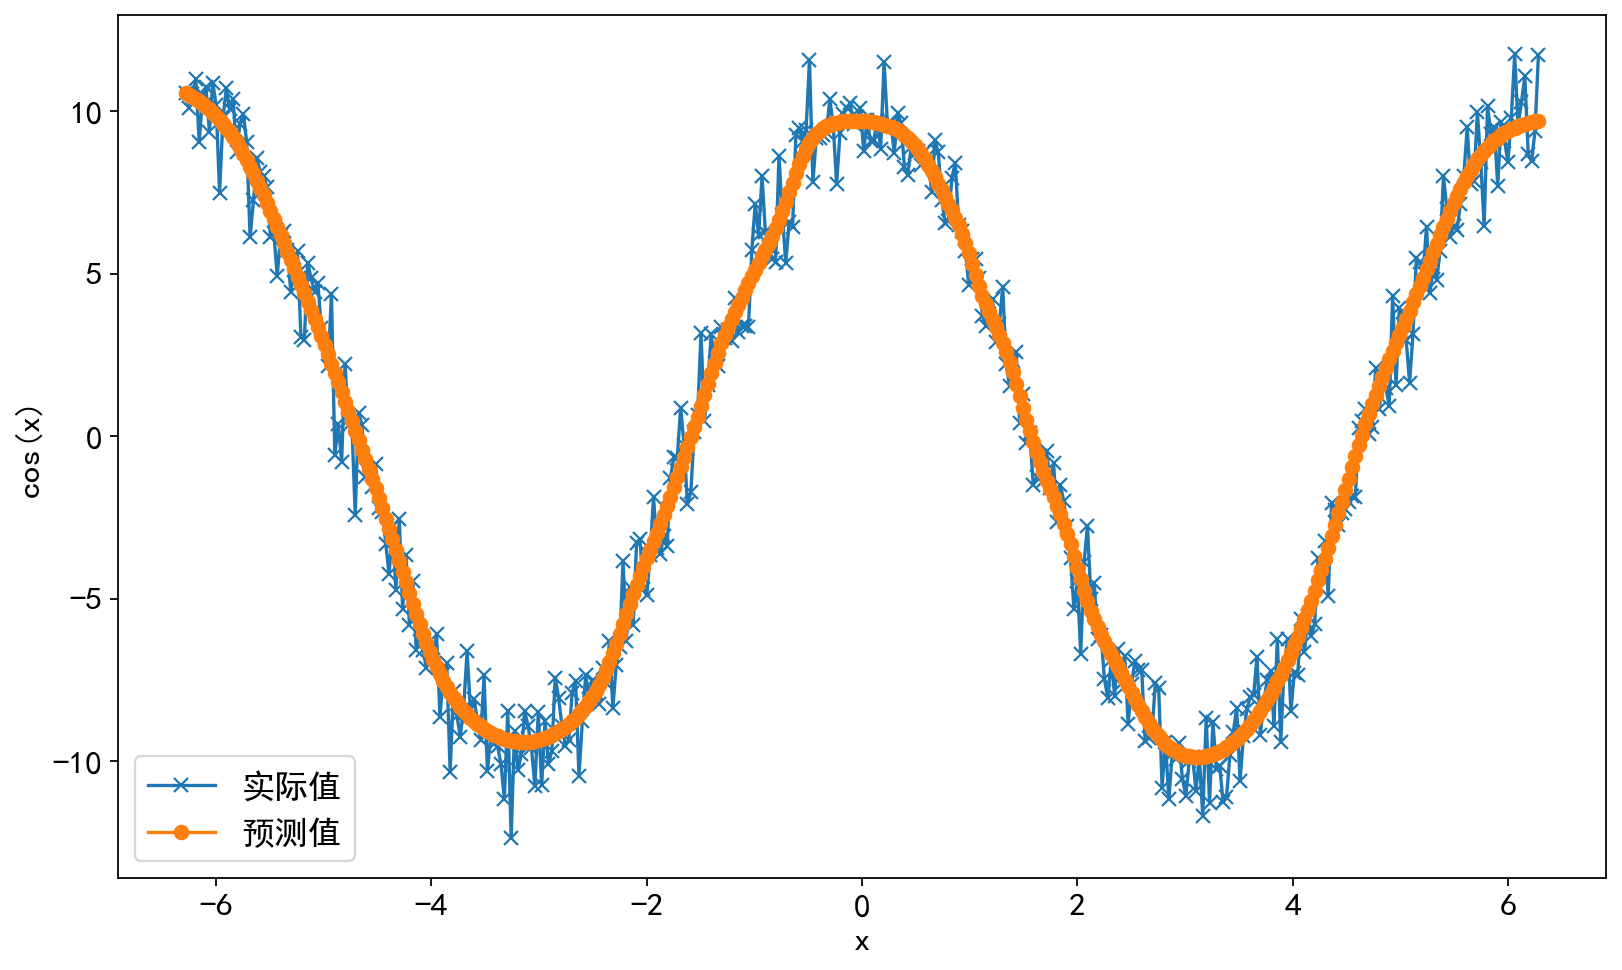

In [7]:
predict=net(torch.tensor(X,dtype=torch.float))
plt.figure(figsize=(12, 7), dpi=160)
plt.plot(x, y , label="实际值", marker = "x")
plt.plot(x, predict.detach().numpy(), label="预测值", marker='o') 
plt.xlabel("x", size=15)
plt.ylabel("cos(x)", size=15)
plt.xticks(size=15)
plt.yticks(size=15)
plt.legend(fontsize=15)
plt.show()